## Part 1- Data Coding and Merging

In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import NHL Team Data and Display
#1
NHL_Team=pd.read_csv("NHL_team.csv")
NHL_Team.drop(['Unnamed: 0', 'abbr','tname', 'lname', 'sname'], axis=1, inplace=True)
NHL_Team.rename(columns={'name':'team_name'}, inplace=True)

display(NHL_Team)

,tid,team_name,tricode
0,1,Toronto Maple Leafs,TOR
1,2,Montréal Canadiens,MTL
2,4,Winnipeg Jets,WPG
3,5,Washington Capitals,WSH
4,6,Chicago Blackhawks,CHI
5,7,St. Louis Blues,STL
6,8,Pittsburgh Penguins,PIT
7,10,Edmonton Oilers,EDM
8,11,Calgary Flames,CGY
9,14,Philadelphia Flyers,PHI


In [3]:
#Import NHL Competition Data and Display Head
#2
NHL_Competition=pd.read_csv("NHL_competition.csv")
NHL_Competition.drop(['Unnamed: 0','tz','start','end'], axis=1, inplace=True)
NHL_Competition.rename(columns={'name':'competition_name'}, inplace=True)
NHL_Competition.head()

,comp_id,year,type,competition_name
0,1,2013,2,2013 NHL Regular Season
1,2,2017,2,2017 NHL Regular Season
2,2453,2013,3,2013 NHL Playoff
3,2541,2017,3,2017 NHL Playoff
4,2661,2012,2,2012 NHL Regular Season


In [4]:
#Import NHL Game Data and Display Head
#3
NHL_Game=pd.read_csv("NHL_game.csv")
NHL_Game.drop(['X','period', 'status'], axis=1, inplace=True)
NHL_Game.head()

,gid,comp_id,date,ascore,hscore,home_away,tid
0,37,2,10/7/2017,NaN,NaN,away,25
1,67,2,10/9/2017,NaN,NaN,away,29
2,154,1,10/14/2013,NaN,NaN,away,29
3,278,1,10/24/2013,NaN,NaN,away,53
4,291,1,10/25/2013,NaN,NaN,away,5


In [5]:
#4
NHL_Game = pd.merge(NHL_Game, NHL_Team, on=['tid'])
#5
NHL_Game = pd.merge(NHL_Game, NHL_Competition, on=['comp_id'])
#6
NHL_Game['hgd'] = NHL_Game.hscore - NHL_Game.ascore
NHL_Game = NHL_Game[pd.notnull(NHL_Game['hgd'])]
NHL_Game.head()

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
2,981,2,12/15/2017,4.0,1.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0
3,1607,2,2/4/2018,4.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-2.0
4,2403,2,3/30/2018,7.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-4.0
5,1541,2,1/31/2018,1.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,2.0
6,1243,2,1/5/2018,1.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0


In [6]:
#7
NHL_Game = NHL_Game.dropna()
NHL_Game.head()

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
2,981,2,12/15/2017,4.0,1.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0
3,1607,2,2/4/2018,4.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-2.0
4,2403,2,3/30/2018,7.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-4.0
5,1541,2,1/31/2018,1.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,2.0
6,1243,2,1/5/2018,1.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0


In [7]:
NHL_Game.shape

(18506, 13)

In [8]:
#8
NHL_Game['date'] = pd.to_datetime(NHL_Game.date)
NHL_Game.head(3)

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
2,981,2,2017-12-15,4.0,1.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0
3,1607,2,2018-02-04,4.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-2.0
4,2403,2,2018-03-30,7.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-4.0


In [9]:
print(NHL_Game.date.max())
print(NHL_Game.date.min())

2018-06-08 00:00:00
2010-10-07 00:00:00


In [10]:
#9
NHL_Game.sort_values(by=['date']).head(15)

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
8424,5666,5662,2010-10-07,4.0,3.0,away,66,Carolina Hurricanes,CAR,2010,2,2010 NHL Regular Season,-1.0
9944,5664,5662,2010-10-07,3.0,2.0,home,8,Pittsburgh Penguins,PIT,2010,2,2010 NHL Regular Season,-1.0
9006,5664,5662,2010-10-07,3.0,2.0,away,14,Philadelphia Flyers,PHI,2010,2,2010 NHL Regular Season,-1.0
9125,5666,5662,2010-10-07,4.0,3.0,home,35,Minnesota Wild,MIN,2010,2,2010 NHL Regular Season,-1.0
8814,5662,5662,2010-10-07,2.0,3.0,home,1,Toronto Maple Leafs,TOR,2010,2,2010 NHL Regular Season,1.0
8697,5662,5662,2010-10-07,2.0,3.0,away,2,Montréal Canadiens,MTL,2010,2,2010 NHL Regular Season,1.0
9742,5672,5662,2010-10-08,3.0,2.0,away,16,San Jose Sharks,SJS,2010,2,2010 NHL Regular Season,-1.0
9546,5681,5662,2010-10-08,2.0,1.0,home,32,Ottawa Senators,OTT,2010,2,2010 NHL Regular Season,-1.0
8975,5679,5662,2010-10-08,0.0,4.0,home,18,Detroit Red Wings,DET,2010,2,2010 NHL Regular Season,4.0
10004,5668,5662,2010-10-08,3.0,4.0,away,6,Chicago Blackhawks,CHI,2010,2,2010 NHL Regular Season,1.0


In [11]:
#10
NHL_Home = NHL_Game[NHL_Game.home_away == 'home'].copy()
NHL_Home.head()

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
41,2254,2,2018-03-20,3.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
42,2050,2,2018-03-07,4.0,5.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
43,844,2,2017-12-06,2.0,6.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,4.0
44,659,2,2017-11-23,2.0,3.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
45,2147,2,2018-03-13,7.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0


In [12]:
#10
NHL_Away = NHL_Game[NHL_Game.home_away == 'away'].copy()
NHL_Away.head()

,gid,comp_id,date,ascore,hscore,home_away,tid,team_name,tricode,year,type,competition_name,hgd
2,981,2,2017-12-15,4.0,1.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0
3,1607,2,2018-02-04,4.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-2.0
4,2403,2,2018-03-30,7.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-4.0
5,1541,2,2018-01-31,1.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,2.0
6,1243,2,2018-01-05,1.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0


In [13]:
NHL_Away = NHL_Away.rename(columns={'ascore':'goals_for','hscore':'goals_against'})
NHL_Home = NHL_Home.rename(columns={'hscore':'goals_for','ascore':'goals_against'})
NHL_Home

,gid,comp_id,date,goals_against,goals_for,home_away,tid,team_name,tricode,year,type,competition_name,hgd
41,2254,2,2018-03-20,3.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
42,2050,2,2018-03-07,4.0,5.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
43,844,2,2017-12-06,2.0,6.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,4.0
44,659,2,2017-11-23,2.0,3.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0
45,2147,2,2018-03-13,7.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18933,5226,5181,2017-04-12,1.0,3.0,home,8,Pittsburgh Penguins,PIT,2016,3,2016 NHL Playoff,2.0
18939,5240,5181,2017-04-16,5.0,0.0,home,6,Chicago Blackhawks,CHI,2016,3,2016 NHL Playoff,-5.0
18940,5238,5181,2017-04-14,1.0,0.0,home,6,Chicago Blackhawks,CHI,2016,3,2016 NHL Playoff,-1.0
18944,5267,5181,2017-04-18,5.0,4.0,home,11,Calgary Flames,CGY,2016,3,2016 NHL Playoff,-1.0


In [14]:
#10
NHL_Home['win'] = np.where(NHL_Home.goals_for > NHL_Home.goals_against, 1, 
                      np.where(NHL_Home.goals_for == NHL_Home.goals_against, 0.5, 0))

NHL_Away['win'] = np.where(NHL_Away.goals_for > NHL_Away.goals_against, 1, 
                           np.where(NHL_Away.goals_for == NHL_Away.goals_against, 0.5, 0))

NHL_Away.head(3)

,gid,comp_id,date,goals_for,goals_against,home_away,tid,team_name,tricode,year,type,competition_name,hgd,win
2,981,2,2017-12-15,4.0,1.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0,1.0
3,1607,2,2018-02-04,4.0,2.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-2.0,1.0
4,2403,2,2018-03-30,7.0,3.0,away,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-4.0,1.0


In [15]:
#pd.set_option('display.max_rows', 50)
#11
NHL_Game = NHL_Home.append(NHL_Away).copy()
NHL_Game

,gid,comp_id,date,goals_against,goals_for,home_away,tid,team_name,tricode,year,type,competition_name,hgd,win
41,2254,2,2018-03-20,3.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0,1.0
42,2050,2,2018-03-07,4.0,5.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0,1.0
43,844,2,2017-12-06,2.0,6.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,4.0,1.0
44,659,2,2017-11-23,2.0,3.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,1.0,1.0
45,2147,2,2018-03-13,7.0,4.0,home,25,Tampa Bay Lightning,TBL,2017,2,2017 NHL Regular Season,-3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18919,5300,5181,2017-04-27,2.0,3.0,away,8,Pittsburgh Penguins,PIT,2016,3,2016 NHL Playoff,-1.0,1.0
18935,5242,5181,2017-04-18,3.0,2.0,away,6,Chicago Blackhawks,CHI,2016,3,2016 NHL Playoff,1.0,0.0
18936,5245,5181,2017-04-21,4.0,1.0,away,6,Chicago Blackhawks,CHI,2016,3,2016 NHL Playoff,3.0,0.0
18942,5265,5181,2017-04-16,3.0,2.0,away,11,Calgary Flames,CGY,2016,3,2016 NHL Playoff,1.0,0.0


In [16]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [17]:
#12
NHL_Team_Stats = NHL_Game.groupby(by=['tid', 'competition_name', 'type'])['win', 'goals_for','goals_against'].sum()
NHL_Team_Stats.reset_index(inplace=True)
display(NHL_Team_Stats)

,tid,competition_name,type,win,goals_for,goals_against
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0
2,1,2012 NHL Playoff,3,3.0,18.0,22.0
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0
...,...,...,...,...,...,...
364,66,2014 NHL Regular Season,2,30.0,191.0,228.0
365,66,2015 NHL Regular Season,2,34.0,195.0,226.0
366,66,2016 NHL Regular Season,2,35.5,219.0,243.0
367,66,2017 NHL Regular Season,2,35.5,227.0,248.0


In [18]:
#13
NHL_Game_Count = NHL_Game.groupby(by=['tid','competition_name','type']).size().reset_index(name='game_count')
display(NHL_Game_Count)

,tid,competition_name,type,game_count
0,1,2010 NHL Regular Season,2,82
1,1,2011 NHL Regular Season,2,40
2,1,2012 NHL Playoff,3,7
3,1,2012 NHL Regular Season,2,46
4,1,2013 NHL Regular Season,2,79
...,...,...,...,...
364,66,2014 NHL Regular Season,2,82
365,66,2015 NHL Regular Season,2,81
366,66,2016 NHL Regular Season,2,82
367,66,2017 NHL Regular Season,2,80


In [19]:
#14.a
NHL_Team_Stats = pd.merge(NHL_Team_Stats, NHL_Game_Count, on=['tid','competition_name','type'])
NHL_Team_Stats.head()

,tid,competition_name,type,win,goals_for,goals_against,game_count
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40
2,1,2012 NHL Playoff,3,3.0,18.0,22.0,7
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79


In [20]:
#14.b
NHL_Team_Stats = pd.merge(NHL_Team_Stats, NHL_Team, on=['tid'])
NHL_Team_Stats.head()

,tid,competition_name,type,win,goals_for,goals_against,game_count,team_name,tricode
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82,Toronto Maple Leafs,TOR
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40,Toronto Maple Leafs,TOR
2,1,2012 NHL Playoff,3,3.0,18.0,22.0,7,Toronto Maple Leafs,TOR
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46,Toronto Maple Leafs,TOR
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79,Toronto Maple Leafs,TOR


In [21]:
#Import NHL PPPK Data and Display Head
#15.1
NHL_PPPK=pd.read_csv("pp.pk.ppgf.csv")
NHL_PPPK.head()

,tricode,pp,pk,ppgf,competition_name
0,ANA,35,27,9.0,2010 NHL Playoff
1,BOS,126,116,22.0,2010 NHL Playoff
2,BUF,48,46,13.0,2010 NHL Playoff
3,CHI,27,39,6.0,2010 NHL Playoff
4,DET,59,55,6.0,2010 NHL Playoff


In [22]:
#15.2
NHL_Team_Stats = pd.merge(NHL_Team_Stats, NHL_PPPK, on=['tricode', 'competition_name'])
NHL_Team_Stats.head()

,tid,competition_name,type,win,goals_for,goals_against,game_count,team_name,tricode,pp,pk,ppgf
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82,Toronto Maple Leafs,TOR,368,426,46.0
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40,Toronto Maple Leafs,TOR,192,182,36.0
2,1,2012 NHL Playoff,3,3.0,18.0,22.0,7,Toronto Maple Leafs,TOR,30,29,5.0
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46,Toronto Maple Leafs,TOR,234,230,39.0
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79,Toronto Maple Leafs,TOR,362,342,61.0


In [23]:
#16
NHL_Team_Stats['win_pct'] = NHL_Team_Stats.win/NHL_Team_Stats.game_count
NHL_Team_Stats['avg_gf'] = NHL_Team_Stats.goals_for / NHL_Team_Stats.game_count
NHL_Team_Stats['avg_ag'] = NHL_Team_Stats.goals_against / NHL_Team_Stats.game_count
NHL_Team_Stats.head()

,tid,competition_name,type,win,goals_for,goals_against,game_count,team_name,tricode,pp,pk,ppgf,win_pct,avg_gf,avg_ag
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82,Toronto Maple Leafs,TOR,368,426,46.0,0.439024,2.719512,3.158537
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40,Toronto Maple Leafs,TOR,192,182,36.0,0.500000,3.225000,3.225000
2,1,2012 NHL Playoff,3,3.0,18.0,22.0,7,Toronto Maple Leafs,TOR,30,29,5.0,0.428571,2.571429,3.142857
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46,Toronto Maple Leafs,TOR,234,230,39.0,0.543478,3.130435,2.804348
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79,Toronto Maple Leafs,TOR,362,342,61.0,0.481013,2.924051,3.164557


In [24]:
#17 
NHL_Team_R_Stats = NHL_Team_Stats[NHL_Team_Stats.type == 2]
NHL_Team_R_Stats.head()

,tid,competition_name,type,win,goals_for,goals_against,game_count,team_name,tricode,pp,pk,ppgf,win_pct,avg_gf,avg_ag
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82,Toronto Maple Leafs,TOR,368,426,46.0,0.439024,2.719512,3.158537
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40,Toronto Maple Leafs,TOR,192,182,36.0,0.500000,3.225000,3.225000
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46,Toronto Maple Leafs,TOR,234,230,39.0,0.543478,3.130435,2.804348
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79,Toronto Maple Leafs,TOR,362,342,61.0,0.481013,2.924051,3.164557
5,1,2014 NHL Regular Season,2,29.0,209.0,258.0,78,Toronto Maple Leafs,TOR,319,343,54.0,0.371795,2.679487,3.307692


## Part 2 - Descriptive and Summary Analyses

In [25]:
NHL_Game.goals_for.describe()

count    18506.000000
mean         2.825894
std          1.654729
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: goals_for, dtype: float64

In [26]:
Goals_home = NHL_Game[NHL_Game.home_away == 'home']
Goals_home.goals_against.describe()

count    9253.000000
mean        2.689830
std         1.608916
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: goals_against, dtype: float64

In [27]:
Goals_away = NHL_Game[NHL_Game.home_away == 'away']
Goals_away.goals_against.describe()

count    9253.000000
mean        2.961958
std         1.688463
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: goals_against, dtype: float64

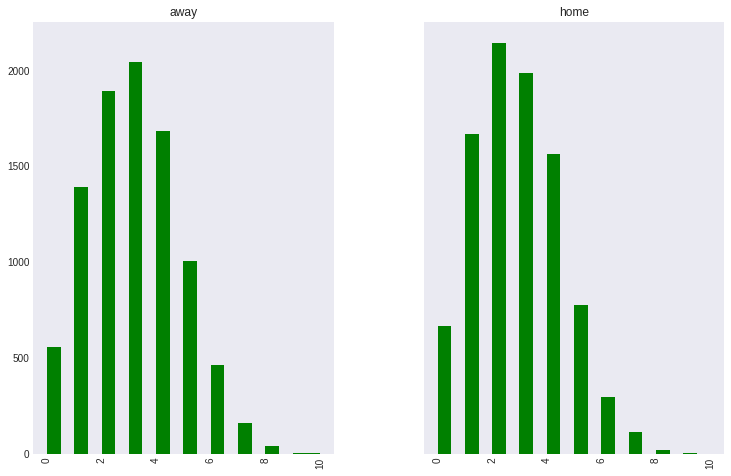

In [28]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,8)
plt.style.use('seaborn-dark')

NHL_Game.hist(by='home_away', column='goals_against', bins=20, color='green', sharex=True, sharey=True);

## Part 3 - Correlation Analyses
In the “NHL_Team_R_Stats” dataframe, make a scatter plot to depict the relationship between the total number of goals for and the winning percentage. 
a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.

In [29]:
print(NHL_Team_R_Stats.columns)

Index(['tid', 'competition_name', 'type', 'win', 'goals_for', 'goals_against',
       'game_count', 'team_name', 'tricode', 'pp', 'pk', 'ppgf', 'win_pct',
       'avg_gf', 'avg_ag'],
      dtype='object')


<AxesSubplot:xlabel='goals_for', ylabel='win_pct'>

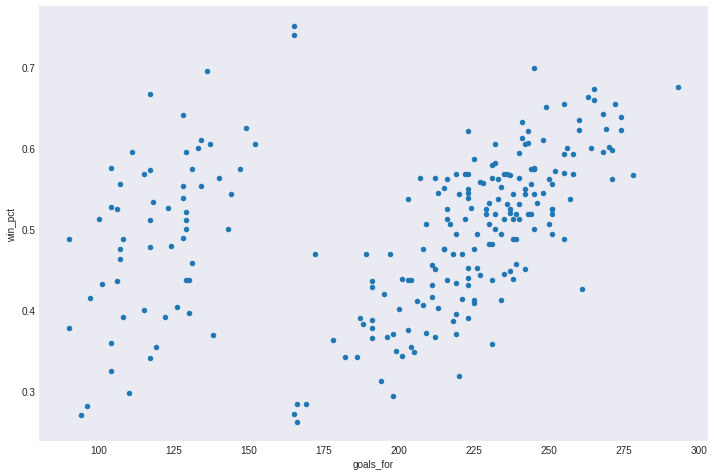

In [30]:
NHL_Team_R_Stats.plot.scatter(x='goals_for', y='win_pct')

b) Add a regression line to the scatter plot.

c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.
d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.

Text(0.5, 1.0, 'Relationship between Goals for and Winning Percentage')

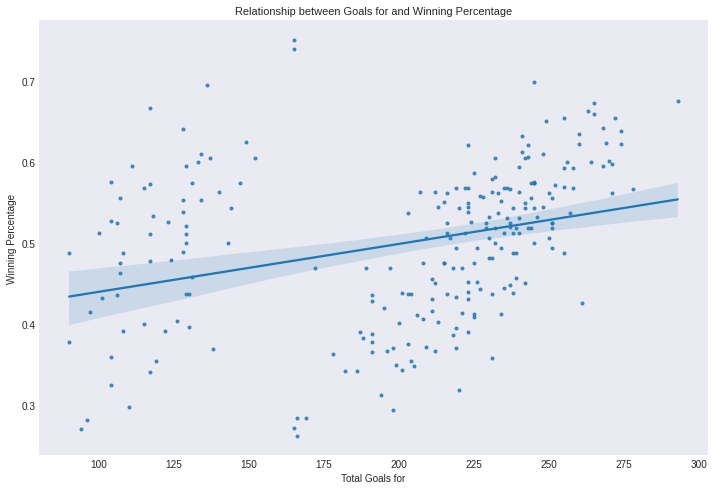

In [31]:
sns.regplot(x='goals_for', y='win_pct', data=NHL_Team_R_Stats, marker='.')
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')
plt.title("Relationship between Goals for and Winning Percentage", fontsize=11)

2. In the “NHL_Team_R_Stats” dataframe, calculate the correlation coefficient between total number of goals for and winning percentage.

In [32]:
 NHL_Team_R_Stats.goals_for.corr(NHL_Team_R_Stats.win_pct)

0.31566456280848143

3. Create a scatter plot of the total number of goals for and winning percentage similar to step 1 for regular season games. In this graph, group observations by “competition_name”.

    a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.

    b) Add a regression line to the scatter plot.

    c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.

    d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.

Text(0.5, 1.0, 'Relationship between Goals and Winning Percentage')

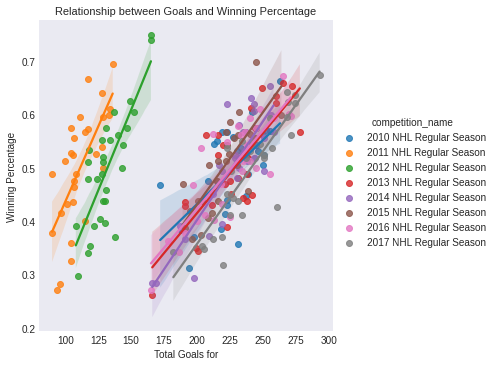

In [33]:
sns.lmplot(x='goals_for', y='win_pct',\
           hue='competition_name', data=NHL_Team_R_Stats)
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')
plt.title('Relationship between Goals and Winning Percentage', fontsize=11)

4. For the “NHL_Team_R_Stats” dataframe, delete observations of 2011 and 2012 seasons. Continue to name the dataframe “NHL_Team_R_Stats”.

In [34]:
NHL_Team_R_Stats.columns
NHL_Team_R_Stats = NHL_Team_R_Stats[NHL_Team_R_Stats.competition_name \
                                    != '2011 NHL Regular Season']
NHL_Team_R_Stats = NHL_Team_R_Stats[NHL_Team_R_Stats.competition_name \
                                    != '2012 NHL Regular Season']                                   
NHL_Team_R_Stats.competition_name.unique()

array(['2010 NHL Regular Season', '2013 NHL Regular Season',
       '2014 NHL Regular Season', '2015 NHL Regular Season',
       '2016 NHL Regular Season', '2017 NHL Regular Season'], dtype=object)

5.In the new “NHL_Team_R_Stats” dataframe, create a scatter plot of total number of goals for and winning percentage.

    a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.
    
    b) Add a regression line to the scatter plot.

    c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.

    d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.

Text(0.5, 1.0, 'Relationship between Goals and Winning Percentage')

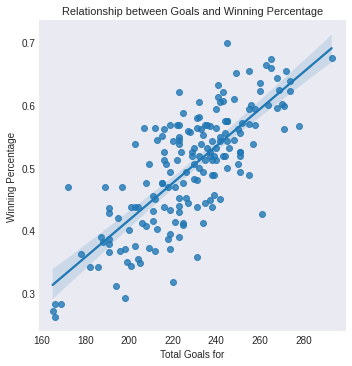

In [35]:
sns.lmplot(x='goals_for', y='win_pct',data=NHL_Team_R_Stats)
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')
plt.title('Relationship between Goals and Winning Percentage', fontsize=11)

6. Calculate the correlation coefficient between total number of goals for and winning percentage in the updated “NHL_Team_R_Stats” dataframe.

In [36]:
NHL_Team_R_Stats.goals_for.corr(NHL_Team_R_Stats.win_pct)

0.7706255321801442

## Uncomment this Section once your assignment is complete

In [37]:
# Save Dataframes as .csv files
NHL_Game.to_csv("NHL_Game2.csv", index=False)
NHL_Team_Stats.to_csv("NHL_Team_Stats.csv", index=False)
NHL_Team_R_Stats.to_csv("NHL_Team_R_Stats.csv", index=False)